In [2]:
import pandas as pd
import  numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from unidecode import unidecode
from nltk.tokenize import  word_tokenize
import nltk
from nltk.corpus import stopwords,wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from google import genai
from google.genai import types
from dotenv import load_dotenv
import os
import time

load_dotenv()

gemini_key = os.getenv('GOOGLE_API_KEY')


inmutable_df = pd.read_parquet('../data/interim/CLASF_data.parquet')
sns.set_theme(palette='bwr',style='white',font='IosevkaTerm NFP')
plt.style.use('dark_background')



In [135]:
df = inmutable_df.copy()
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,y
index,,,,,,,,,,,
0,5,Nice,If i had a dollar for how many times I have pl...,[],B004RQ2IRG,B004RQ2IRG,AFUOYIZBU3MTBOLYKOJE5Z35MBDA,2021-04-21 02:36:53.292,0,True,digital_music
1,5,Excellent,awesome sound - cant wait to see them in perso...,[],B0026UZEI0,B0026UZEI0,AHGAOIZVODNHYMNCBV4DECZH42UQ,2011-06-15 19:52:05.000,0,True,digital_music
2,5,Great service,This is a great cd. Good music and plays well....,[],B0055JSYHC,B0055JSYHC,AFGEM6BXCYHUILEOA3P2ZYBEF2TA,2021-03-15 20:06:33.006,0,True,digital_music
3,1,No good,"These are not real German singers, they have a...",[],B000F9SMUQ,B000F9SMUQ,AH3OG6QD6EDJGZRVCFKV4B66VWNQ,2014-07-13 02:49:01.000,0,True,digital_music
4,3,"Cool concept, so-so execution...",I first heard this playing in a Nagoya shop an...,[],B0049D1WVK,B0049D1WVK,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,2011-06-25 19:19:55.000,0,False,digital_music


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 370557 entries, 0 to 16215
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             370557 non-null  int64         
 1   title              370557 non-null  object        
 2   text               370557 non-null  object        
 3   images             370557 non-null  object        
 4   asin               370557 non-null  object        
 5   parent_asin        370557 non-null  object        
 6   user_id            370557 non-null  object        
 7   timestamp          370557 non-null  datetime64[ns]
 8   helpful_vote       370557 non-null  int64         
 9   verified_purchase  370557 non-null  bool          
 10  y                  370557 non-null  object        
dtypes: bool(1), datetime64[ns](1), int64(2), object(7)
memory usage: 31.5+ MB


In [137]:

# la unica variable cuyo tipo de dato no es el mas adecuado es el de verified purchase, vamos a tratar eso
df['verified_purchase'] = df['verified_purchase'].astype('int')


In [138]:
df.describe()

,rating,timestamp,helpful_vote,verified_purchase
count,370557.000000,370557,370557.000000,370557.000000
mean,4.411950,2017-08-19 04:11:00.187616,1.796458,0.838095
min,1.000000,1997-09-18 04:38:56,0.000000,0.000000
25%,5.000000,2015-07-20 02:09:38,0.000000,1.000000
50%,5.000000,2018-02-11 00:19:38.172999936,0.000000,1.000000
75%,5.000000,2020-07-12 04:05:25.062000128,1.000000,1.000000
max,5.000000,2023-09-06 22:41:39.945000,4536.000000,1.000000
std,1.222937,NaN,18.139898,0.368364


Vale tenemos pocas variables numericas, no es sorpresa. El predictor de mayor interes es la variable `review`
que es la que a priori se comncibe como el mejor predictor. Por lo tanto este problema cae en el area de NLP.

echemos un ojo a la variable de respuesta

<Axes: xlabel='count', ylabel='y'>

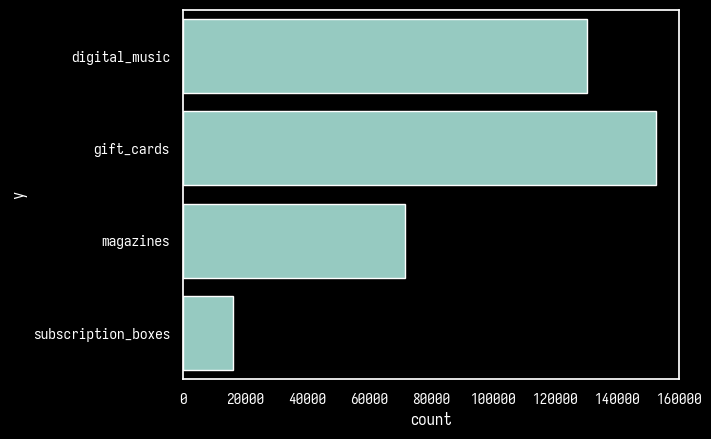

In [139]:
sns.countplot(df['y'])

Existe un claro desbalance en la variable de respuesta, el nivel prominente es `gift__cards`
un posible aproach a este problema puede ser el de elegir una categoria que nos interesa mas a predecir y centrarnos exclusivamente en  predecir esta misma, volviendo el problema a uno de clasificacion binaria

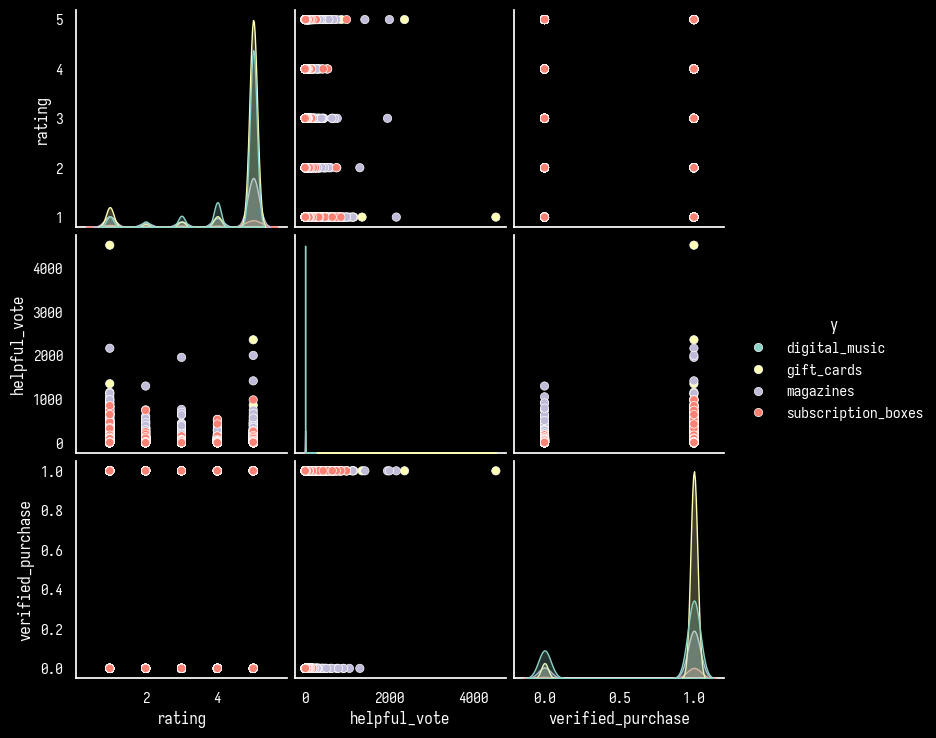

In [140]:
# Analisis de features numericas
sns.pairplot(df,hue='y')

Aparentemente la variable `helpful vote` pareciera separar `subscription boxes` de el resto de las otras categorias, puede ser de utilidad

este puede deberse a que no hay tantas compras de sunscription boxes y por lo tanto hay menos actividad en estos comentarios

# Tirando lo que no sirve

No estamos haciendo seleccion de variables, pero hay ciertas variables que son completamente colineares con la variable de respuesta y que bajo el supuesto del problema, no tendriamos a priori, por lo tanto no podemos usarlas porque introducen leakage
dichas variables son asin y parent_asin que son completamente colineares con  con el producto y por lo tanto no podemos usarlas 

In [141]:
df = df.drop(columns=['parent_asin','asin','images'])



# Procesando el texto

las tareas de NLP podemos representar nuestras entradas de texto como una serie de features o vectores numericos  que podemos obtener de diferentes forma. El como obtenemos este vector es fundamental para los resultados que podemos ontener

- BoW bag of words + hashing
- TfiDF encoding
- embeding

BoW es el aproach mas naive en el que tenemos un vector que representa el numero de apariciones de una palabra dada en un corpus, no sabemos que palabra, solamente contamos con el _conteo_ de cuantas veces aparecio en una frase o texto
TfiDF de manera similar representa la importancia de una palabra o `token` atraves de su aparicion en un texto o documento respecto a su aparicion en otro conjunto mas grande de  textos o documentos

ambos Bow y TfiDF son encodeos basados meramente en la frecuencia u en el conteo de palabras y dejan de lado por completo la semantica de dichas palabras.

Embeding
el embeding consiste en representar palabras, documentos o parrafos con un vector  en un espacio $\mathbb{R}^n$ con la peculiaridad de que se encodea la semantica  y el significado de dichos corpus.

Se explico de manera somera las diferentes maneras de encodeo que tenemos disponibles pero mas delante explicaremos cada una de ellas en mayor profundidad

## Normalizacion de texto

In [142]:
df['text'] = df['text'].map( lambda x : unidecode(x).lower())
df['text']

index
0        if i had a dollar for how many times i have pl...
1        awesome sound - cant wait to see them in perso...
2        this is a great cd. good music and plays well....
3        these are not real german singers, they have a...
4        i first heard this playing in a nagoya shop an...
                               ...                        
16211    my husband loved it and look forward to seeing...
16212    y'all can do so much better. one pop one mini?...
16213    i've been a member for a few years now and i'v...
16214    first few boxes were great. higher value items...
16215    each product in the box is cheap plastic gadge...
Name: text, Length: 370557, dtype: object

In [143]:
# chequeamos que solo queden caracteres comunes
# cortesia de https://es.stackoverflow.com/questions/401468/c%C3%B3mo-elimino-los-signos-de-puntuaci%C3%B3n-de-mi-texto
df['text'] = df['text'].map(lambda x : re.sub(r'[^\w\s]','',x))
df['text']

index
0        if i had a dollar for how many times i have pl...
1        awesome sound  cant wait to see them in person...
2        this is a great cd good music and plays well s...
3        these are not real german singers they have ac...
4        i first heard this playing in a nagoya shop an...
                               ...                        
16211    my husband loved it and look forward to seeing...
16212    yall can do so much better one pop one mini co...
16213    ive been a member for a few years now and ive ...
16214    first few boxes were great higher value items ...
16215    each product in the box is cheap plastic gadge...
Name: text, Length: 370557, dtype: object

In [144]:
# verificamos que solo queden caracteres comunes
for i in df['text'].values:
    c = 0

    t = re.fullmatch(r'^[A-Za-z0-9 ]+$',i)
    if t == None:

        c += 1
print(f'Numero de palabras con caracteres raros: {c}')


Numero de palabras con caracteres raros: 0


Hermoso, el siguiente paso es tokenizar nuestro texto. Elegi tokenizacion por palabra, no hay una razon especifica para esto, bien podriamos intentar tokenizacion por frases o por n-gramas, esto es algo que quizas podriamos ajustar mas delante dependiendo del performance del modelo

In [145]:

nltk.download('punkt')
nltk.download('punkt_tab')
word_tokenize(df['text'].values[0])



[nltk_data] Downloading package punkt to /home/arroio/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/arroio/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['if',
 'i',
 'had',
 'a',
 'dollar',
 'for',
 'how',
 'many',
 'times',
 'i',
 'have',
 'played',
 'this',
 'cd',
 'and',
 'how',
 'many',
 'times',
 'i',
 'have',
 'asked',
 'alexa',
 'to',
 'play',
 'it',
 'i',
 'would',
 'be',
 'rich',
 'love',
 'this',
 'singer',
 'along',
 'with',
 'the',
 'black',
 'pumas',
 'finding',
 'a',
 'lot',
 'of',
 'new',
 'music',
 'that',
 'i',
 'like',
 'a',
 'lot',
 'on',
 'amazon',
 'try',
 'new',
 'things']

Todo funciona piola ahora vamos a aplicarlo a toda la columna

In [146]:
df['text'] = df['text'].map(lambda x: word_tokenize(x))
df['text']

index
0        [if, i, had, a, dollar, for, how, many, times,...
1        [awesome, sound, cant, wait, to, see, them, in...
2        [this, is, a, great, cd, good, music, and, pla...
3        [these, are, not, real, german, singers, they,...
4        [i, first, heard, this, playing, in, a, nagoya...
                               ...                        
16211    [my, husband, loved, it, and, look, forward, t...
16212    [yall, can, do, so, much, better, one, pop, on...
16213    [ive, been, a, member, for, a, few, years, now...
16214    [first, few, boxes, were, great, higher, value...
16215    [each, product, in, the, box, is, cheap, plast...
Name: text, Length: 370557, dtype: object

In [147]:
# elminacion de stopwords 

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
df['text'] = df['text'].map(lambda x: [w for w in x if not w in stop_words])
df['text']



[nltk_data] Downloading package stopwords to /home/arroio/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


index
0        [dollar, many, times, played, cd, many, times,...
1        [awesome, sound, cant, wait, see, person, alwa...
2        [great, cd, good, music, plays, well, seller, ...
3        [real, german, singers, accents, nothing, adve...
4        [first, heard, playing, nagoya, shop, fell, lo...
                               ...                        
16211    [husband, loved, look, forward, seeing, shirts...
16212      [yall, much, better, one, pop, one, mini, come]
16213    [ive, member, years, ive, yet, disappointed, i...
16214    [first, boxes, great, higher, value, items, pr...
16215    [product, box, cheap, plastic, gadgetsbr, br, ...
Name: text, Length: 370557, dtype: object

El siguiente paso es lemmatizar o stmmear nuestro texto

la lemmatizacion es el proceso de reducir las palabras de nuestro texto a su _raiz_ por ejemplo la palabra `manzana` y `manzanas` no tienen relacion aparente en primer momento a ojos de una compiutadora, no obstante con la lemmatizacion estas palabras se reducen a la misma raiz (alch no estoy seguro, es un ejemplo jajaj) lo que ayuda a disinuir la granularidad de nuestro texto y beneficiar de esto al embedding o al tfidf

la lemmatizacion por otra parte es un proceso que consta de igual manera en reducir palabras a su lemma (_raiz_) pero tambien en eliminar sufijos (no me acuerdo que es eso) en  las palabras que pueden ser conflictivos. 

En general los algoritmos de stemmatizacion tiene un fundamento predominante en el analisis linguistico y de sintaxis de un idioma, por lo que especificar exhaustivamente estos algoritmos escapa del scope de la materia y basta con entender que la stemmatizacion se utiliza para quitar afijos de palabras 

estoy aprendiendo mas de español haciendo esto que en COE

[fuente](https://www.ibm.com/think/topics/stemming-lemmatization)

Siendo completamente sincero  no conozco de algun criterio para utilizar uno u otro, mas alla de que la lemmatizacion es un proceso mas robusto y costoso

esto debido a que la stemmatizacion transforma las palabras en base a _reglas_ implementadas en el algoritmo para reducir los afijos y otros elementos, este proceso aveces reduce al lemma, aveces no (_under_stemm_) o a veces reduce dos palabras con significados diferentes al mismo lemma _e.g._ `new` y `news` ademas que para algunas palabras no regresa una palabra ya que eliminando los sufijos no se llega a su lemma, por ejemplo el stemmer de potter que es el mas utilizado reduce `nothing -> noth` lo cual no es siquiera una palabra

por otra parte lemmatizacion hace un `mapeo` de una palabra a su raiz basandose atraves de una base de datos de un lenguaje, lo cual nos garantiza que nuestro outcome es una palabra real.
esta base de datos  no es simplemente una lista enorme de claves y valores sino que cada lemmatizer y cada base de datos hace uso  de funciones auxiliares que hacen queries dentro de la base de datos  para llegar a candidatos de lemas y filtrarlos hasta que llegamos a la respuesta.

por ejemplo para el lemmatizer que vamos a utilizar por debajo del capo se utiliza la [`morphy`](https://wn.readthedocs.io/en/latest/api/wn.morphy.html) function que viene junto con la base de datos que usamos para el ingles, la cual es `WordNet`
dentro de esa funcion es donde se encuentra toda la carnita y toda la magia de este lemmatizer


In [148]:
# ejemplo

nltk.download('wordnet')


lemmatizer = WordNetLemmatizer()

word = 'wiser'

lemmatizer.lemmatize(word,pos='a')





[nltk_data] Downloading package wordnet to /home/arroio/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


'wise'

 Notese que tenemos que pasarle un argumento llamado pos, esto dice si es verbo adjetivo o adverbio 

In [149]:
# obtener el argumento pos
nltk.download('averaged_perceptron_tagger_eng')

def get_wordnet_pos(tag):
    
    
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:         
        return wordnet.NOUN


def lemmatize_list(x):
    pos_tags = pos_tag(x)
    
    tags = [t[1]for t in pos_tags]

    final_tags = [get_wordnet_pos(t) for t in tags]

    final_list_words = [lemmatizer.lemmatize(w,t) for w,t in zip(x,final_tags)]
    return final_list_words



df['text'] = df['text'].map(lambda x: lemmatize_list(x))
df['text']

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/arroio/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


index
0        [dollar, many, time, play, cd, many, time, ask...
1        [awesome, sound, cant, wait, see, person, alwa...
2        [great, cd, good, music, play, well, seller, r...
3        [real, german, singer, accent, nothing, advert...
4        [first, hear, play, nagoya, shop, fell, love, ...
                               ...                        
16211    [husband, love, look, forward, see, shirt, add...
16212        [yall, much, good, one, pop, one, mini, come]
16213    [ive, member, year, ive, yet, disappointed, it...
16214    [first, boxes, great, high, value, item, prese...
16215    [product, box, cheap, plastic, gadgetsbr, br, ...
Name: text, Length: 370557, dtype: object

In [150]:
# vamos a hacer un checkpoint porque eso fue muy tardado

df1 = df.copy()

In [151]:
df1

,rating,title,text,user_id,timestamp,helpful_vote,verified_purchase,y
index,,,,,,,,
0,5,Nice,"[dollar, many, time, play, cd, many, time, ask...",AFUOYIZBU3MTBOLYKOJE5Z35MBDA,2021-04-21 02:36:53.292,0,1,digital_music
1,5,Excellent,"[awesome, sound, cant, wait, see, person, alwa...",AHGAOIZVODNHYMNCBV4DECZH42UQ,2011-06-15 19:52:05.000,0,1,digital_music
2,5,Great service,"[great, cd, good, music, play, well, seller, r...",AFGEM6BXCYHUILEOA3P2ZYBEF2TA,2021-03-15 20:06:33.006,0,1,digital_music
3,1,No good,"[real, german, singer, accent, nothing, advert...",AH3OG6QD6EDJGZRVCFKV4B66VWNQ,2014-07-13 02:49:01.000,0,1,digital_music
4,3,"Cool concept, so-so execution...","[first, hear, play, nagoya, shop, fell, love, ...",AFW2PDT3AMT4X3PYQG7FJZH5FXFA,2011-06-25 19:19:55.000,0,0,digital_music
...,...,...,...,...,...,...,...,...
16211,5,Very pleased,"[husband, love, look, forward, see, shirt, add...",AGX4UTCIP4SGTHHDA4E3WGPIJFBQ,2020-12-24 21:50:27.043,0,1,subscription_boxes
16212,1,??????,"[yall, much, good, one, pop, one, mini, come]",AH4WBYSLGIAMVLCT2PPRTMNNJD6A,2019-03-16 19:32:07.421,1,1,subscription_boxes
16213,5,Always a great surprise inside,"[ive, member, year, ive, yet, disappointed, it...",AHUTNTBX5E65YNIHI2ERA2AMFM4Q,2019-12-05 21:09:56.049,13,0,subscription_boxes


# Embedings


Debido a que nuestro texto tiene longitud variable considero que lo mas adecuado es un sentence embeding en lugar de un word2vec



In [152]:
df1['text'] = df1['text'].map(lambda x: ' '.join(x))
df1['text'].values

array(['dollar many time play cd many time ask alexa play would rich love singer along black puma find lot new music like lot amazon try new thing',
       'awesome sound cant wait see person always miss town',
       'great cd good music play well seller respond back quicky receive within 3 day',
       ...,
       'ive member year ive yet disappointed item always great surprise',
       'first boxes great high value item presentation box bag add perceived value subscription continue item become gimmicky hung last box near value pay box odd send question tell absolutely box send picture receive sent picture tell try deliver environmentally friendly way since always repurposed box state come box im feel great quality control save 170 company least story straight disappoint',
       'product box cheap plastic gadgetsbr br 1 automatic soap dispenser receive doesnt hold chargebr br 2 palladium ear bud awfulbr br 3 uv wand doesnt actually clean anything im sure actually product market wayb

In [153]:
# Toca hacer lo mismo para la variable del titulo

df1['title'] = df1['title'].map( lambda x : unidecode(x).lower())
df1['title'] = df1['title'].map(lambda x : re.sub(r'[^\w\s]','',x))
# verificamos que solo queden caracteres comunes
for i in df1['title'].values:
    c = 0

    t = re.fullmatch(r'^[A-Za-z0-9 ]+$',i)
    if t == None:

        c += 1
print(f'Numero de palabras con caracteres raros: {c}')

# para que la funcion lemmatize_list funcione
df1['title'] =  df1['title'].map(lambda x: [x])
df1['title'] = df1['title'].map(lambda x: lemmatize_list(x))
df1['title'] = df1['title'].map(lambda x: ' '.join(x))
df1['title']


Numero de palabras con caracteres raros: 0


index
0                                                     nice
1                                                excellent
2                                            great service
3                                                  no good
4                              cool concept soso execution
                               ...                        
16211                                         very pleased
16212                                                     
16213                       always a great surprise inside
16214    if youre looking for a box you have the wrong ...
16215            cheap plastic gadgets you would never buy
Name: title, Length: 370557, dtype: object

In [154]:
# vamos guardando el frame lemmatizado

df1.to_parquet('../data/interim/CLASF_lemmatized_data.parquet')

In [5]:
df_lemm = pd.read_parquet('../data/interim/CLASF_lemmatized_data.parquet')


In [6]:
# hay algunas columnas que quedaron con textos vacios
df_lemm[df_lemm['text'] == ''].shape

(1428, 8)

In [7]:
# son bastante pocos vamos a quitarlos
df_lemm = df_lemm.drop(df_lemm[df_lemm['text'] == ''].index)

df_lemm[df_lemm['text'] == '']

,rating,title,text,user_id,timestamp,helpful_vote,verified_purchase,y
index,,,,,,,,


In [5]:
df_lemm

,rating,title,text,user_id,timestamp,helpful_vote,verified_purchase,y
index,,,,,,,,
0,5,nice,dollar many time play cd many time ask alexa p...,AFUOYIZBU3MTBOLYKOJE5Z35MBDA,2021-04-21 02:36:53.292,0,1,digital_music
1,5,excellent,awesome sound cant wait see person always miss...,AHGAOIZVODNHYMNCBV4DECZH42UQ,2011-06-15 19:52:05.000,0,1,digital_music
2,5,great service,great cd good music play well seller respond b...,AFGEM6BXCYHUILEOA3P2ZYBEF2TA,2021-03-15 20:06:33.006,0,1,digital_music
3,1,no good,real german singer accent nothing advertise mu...,AH3OG6QD6EDJGZRVCFKV4B66VWNQ,2014-07-13 02:49:01.000,0,1,digital_music
4,3,cool concept soso execution,first hear play nagoya shop fell love remix ke...,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,2011-06-25 19:19:55.000,0,0,digital_music
...,...,...,...,...,...,...,...,...
16211,5,very pleased,husband love look forward see shirt add collec...,AGX4UTCIP4SGTHHDA4E3WGPIJFBQ,2020-12-24 21:50:27.043,0,1,subscription_boxes
16212,1,,yall much good one pop one mini come,AH4WBYSLGIAMVLCT2PPRTMNNJD6A,2019-03-16 19:32:07.421,1,1,subscription_boxes
16213,5,always a great surprise inside,ive member year ive yet disappointed item alwa...,AHUTNTBX5E65YNIHI2ERA2AMFM4Q,2019-12-05 21:09:56.049,13,0,subscription_boxes


# Ahora si, embeddings

Para realizar el embedding haremos uso de la api de gemini, por lo que es probable que no pueda correrlo apartir de aqui, cada texto al que le hagamos embedding resultara en un vector $v \in \mathbb{R}^{768}$


In [ ]:

client = genai.Client(api_key=gemini_key)

n_rows = df_lemm['text'].shape[0]
chunk_size = 100

emb_m = []
for i in range(0,n_rows,chunk_size):

    
    if i % 3000 == 0 and i != 0 :
        print('pausita')
        time.sleep(65)
    
    if i % 70000 == 0 and i!= 0:
        print('pausota')
        time.sleep(300)
    
    
    
    
    print(i)
    result = client.models.embed_content(
        model="gemini-embedding-001",
        contents= df_lemm['text'].values.tolist()[i: i + chunk_size],
    config=types.EmbedContentConfig(output_dimensionality=768)
)

    embedings_matrix = np.array([emb.values for emb in result.embeddings])
    emb_m.append(embedings_matrix)


embedings = np.concatenate(emb_m)

In [158]:
df_lemm.shape

(366889, 8)

In [ ]:
vec_cols = [f'w{i + 1}' for i in range(embedings.shape[1])]

df_vec = pd.DataFrame(embedings,columns=vec_cols)
df_vec.to_parquet('../data/interim/emb_vecs.parquet')
# un checkpoint mas para que no se me llene la ram

In [3]:
df_vec = pd.read_parquet('../data/interim/emb_vecs.parquet')

In [8]:
df_final = pd.concat([df_lemm.reset_index(drop=True),df_vec],axis=1)
df_final

,rating,title,text,user_id,timestamp,helpful_vote,verified_purchase,y,w1,w2,...,w759,w760,w761,w762,w763,w764,w765,w766,w767,w768
0,5,nice,dollar many time play cd many time ask alexa p...,AFUOYIZBU3MTBOLYKOJE5Z35MBDA,2021-04-21 02:36:53.292,0,1,digital_music,0.000443,-0.022210,...,0.022790,0.019902,0.007157,-0.022869,-0.034202,0.014241,-0.003694,-0.004159,0.023721,-0.003433
1,5,excellent,awesome sound cant wait see person always miss...,AHGAOIZVODNHYMNCBV4DECZH42UQ,2011-06-15 19:52:05.000,0,1,digital_music,-0.031745,-0.019814,...,0.024561,-0.020305,-0.020279,0.005201,-0.028544,0.009970,0.008552,0.019862,0.019696,0.017286
2,5,great service,great cd good music play well seller respond b...,AFGEM6BXCYHUILEOA3P2ZYBEF2TA,2021-03-15 20:06:33.006,0,1,digital_music,0.002324,-0.010708,...,0.011160,0.011424,-0.039464,-0.007070,-0.027563,0.003449,0.015970,0.022061,0.027887,0.011086
3,1,no good,real german singer accent nothing advertise mu...,AH3OG6QD6EDJGZRVCFKV4B66VWNQ,2014-07-13 02:49:01.000,0,1,digital_music,-0.021712,-0.014616,...,0.013747,0.018405,-0.019282,0.013659,-0.016365,-0.001689,0.025930,0.009063,0.027928,0.010849
4,3,cool concept soso execution,first hear play nagoya shop fell love remix ke...,AFW2PDT3AMT4X3PYQG7FJZH5FXFA,2011-06-25 19:19:55.000,0,0,digital_music,-0.007354,-0.001755,...,-0.003726,0.010124,-0.009167,-0.018006,-0.014497,-0.007062,-0.000024,0.029641,0.039546,-0.015668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366884,5,very pleased,husband love look forward see shirt add collec...,AGX4UTCIP4SGTHHDA4E3WGPIJFBQ,2020-12-24 21:50:27.043,0,1,subscription_boxes,-0.044188,-0.030955,...,-0.002998,-0.022135,-0.011051,-0.019261,-0.010035,0.004723,0.014171,0.034722,0.009844,0.007566
366885,1,,yall much good one pop one mini come,AH4WBYSLGIAMVLCT2PPRTMNNJD6A,2019-03-16 19:32:07.421,1,1,subscription_boxes,0.004292,0.004077,...,0.004391,-0.001886,-0.007506,-0.005155,-0.004811,-0.002218,0.000209,0.021860,0.017914,-0.012674
366886,5,always a great surprise inside,ive member year ive yet disappointed item alwa...,AHUTNTBX5E65YNIHI2ERA2AMFM4Q,2019-12-05 21:09:56.049,13,0,subscription_boxes,-0.014395,-0.003851,...,-0.007549,-0.013036,-0.010625,0.004988,-0.017839,-0.013251,-0.002387,-0.016752,-0.007194,-0.010930
366887,1,if youre looking for a box you have the wrong ...,first boxes great high value item presentation...,AF6RXEUYBSSOMO5RSS23OPB5QKSA,2022-06-29 13:42:43.413,6,1,subscription_boxes,-0.006225,-0.018080,...,0.017925,-0.023601,-0.000785,-0.022576,-0.028158,-0.016510,0.001594,0.003268,0.015738,0.010525


In [9]:
# volvemos a asgurarnos que no haya nulos
df_final = df_final.drop(df_final[df_final['text'] == ''].index)

df_final[df_final['text'] == '']

,rating,title,text,user_id,timestamp,helpful_vote,verified_purchase,y,w1,w2,...,w759,w760,w761,w762,w763,w764,w765,w766,w767,w768


In [10]:
df_final.isna().sum()

rating       0
title        0
text         0
user_id      0
timestamp    0
            ..
w764         0
w765         0
w766         0
w767         0
w768         0
Length: 776, dtype: int64

## normalizando los vectores
es comun  en trabajos de NLP normalizar los vectores de embedding de un texto, esto es que su norma $l_2$ sea uno: $\lvert\lvert v\rvert\rvert_2 = 1$. Esto se hace por variedad de razones.nos ayuda reducir todas nuestras representaciones de texto a una bola de radio 1 centrada en 0, ademas nos ayuda a obtener la norma de la proyeccion  de un vector a otro de forma sencilla


$$\lvert \lvert \text{proj}_u v\rvert\rvert = \frac{|u \cdot v|}{||u||}$$

pero desde que $|u|=1 \therefore ||\text{proj}_u v||  = ||\text{proj}_v u|| = u \cdot v $

este tema de las proyecciones hasta donde tengo entendido ayuda a optimizar algoritmos de busqueda con estas bases de datos vectoriales.


pasa algo similar con la cosine similarity, una metrica que es mas de nuestro interes, la distancia coseno nos dice que tanto se parecen semanticamente 2 textos. Recordando que la formula de cauchy-swartz dice

$$\cos \theta = \frac{u \cdot v}{||u|| ||v||}$$
desde que dejamos los vectores unitarios 

$$\cos \theta = u \cdot v$$

algo bastante sencillo y barato de calcular

In [11]:
# liberando espacio para que no me truene el kernel

del inmutable_df
del df_lemm
del df_vec

In [12]:
norms = np.linalg.norm(df_final.iloc[:,8:].values,axis=1)

In [13]:

norms.shape

(366889,)

In [14]:
# verificamos que nos da lo mismo que la primera fila
norms[0],np.linalg.norm(df_final.iloc[0,8:])


(np.float64(0.5919068445891876), np.float64(0.5919068445891876))

In [15]:
df_final.iloc[:,8:] = df_final.iloc[:,8:].div(norms,axis=0) 

In [16]:
# ya esta normalizaaao

np.linalg.norm(df_final.iloc[:,8:].values,axis=1).mean()

np.float64(1.0)

In [17]:
df_final.to_parquet('../data/processed/CLASF_data.parquet')

# analizando cosine similarities 

Como ya mencionamos las cosine similarities es usada para ver similitudes semanticas entre los embeddings, vamos a compararlas en base al target




In [18]:
vec_cols = df_final.columns[8:]
sample_y1 = df_final.loc[df_final['y'] == 'digital_music',vec_cols].sample(n=1000)
sample_y2 = df_final.loc[df_final['y'] == 'gift_cards',vec_cols].sample(n=1000)
sample_y3 = df_final.loc[df_final['y'] == 'magazines',vec_cols].sample(n=1000)
sample_y4 = df_final.loc[df_final['y'] == 'subscription_boxes',vec_cols].sample(n=1000)

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

sim_y1 = cosine_similarity(sample_y1)
sim_y2 = cosine_similarity(sample_y2)
sim_y3 = cosine_similarity(sample_y3)
sim_y4 = cosine_similarity(sample_y4)




Text(0.5, 1.0, 'Cosine similarity entre digital music 0.5530042661429823')

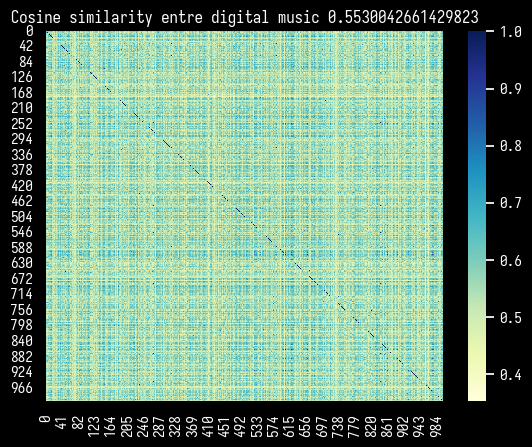

In [25]:
sns.heatmap(sim_y1,cmap='YlGnBu')


plt.title(f'Cosine similarity entre digital music {sim_y1.mean()}')


Text(0.5, 1.0, 'Cosine similarity entre gift cards 0.5687190143931673')

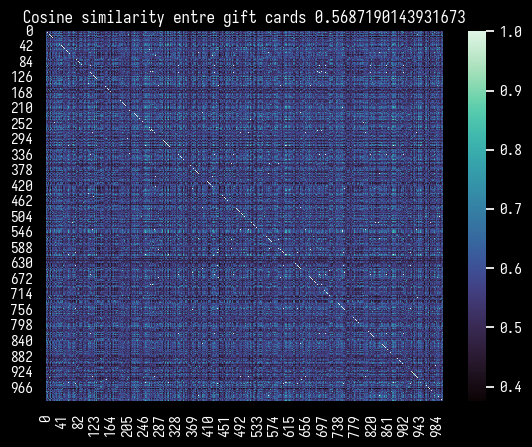

In [26]:
sns.heatmap(sim_y2,cmap='mako')


plt.title(f'Cosine similarity entre gift cards {sim_y2.mean()}')


Text(0.5, 1.0, 'Cosine similarity entre magazines 0.5794804173045415')

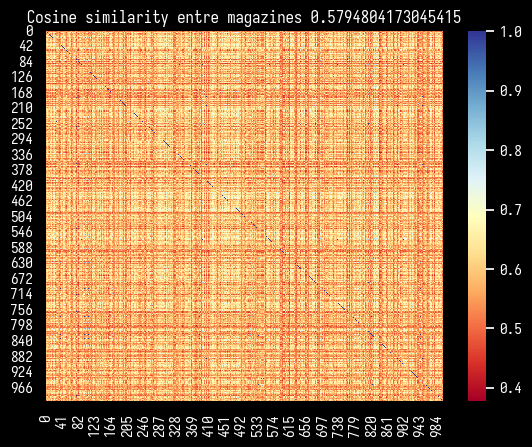

In [27]:
sns.heatmap(sim_y3,cmap='RdYlBu')


plt.title(f'Cosine similarity entre magazines {sim_y3.mean()}')


Text(0.5, 1.0, 'Cosine similarity entre subscription boxes 0.5746548450750598')

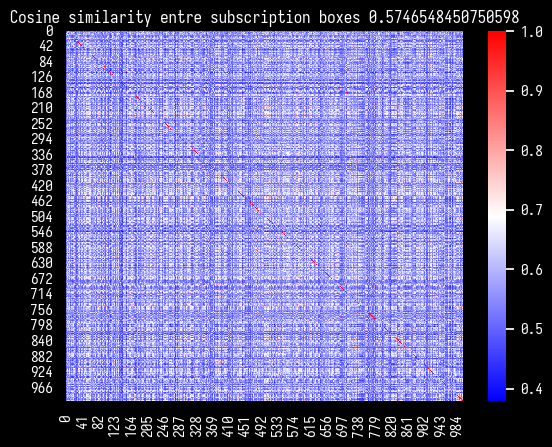

In [28]:
sns.heatmap(sim_y4,cmap='bwr')



plt.title(f'Cosine similarity entre subscription boxes {sim_y4.mean()}')


De priemras dentro del mismo grupo no hay una similitud espectacular y argumentablemente se esta viendo arrastrada por la diagonal, estamos usando una muestra pequeña, no se si condiderar este patron como homogeneo, en teoria los datos son independientes y deberia ser producto del randomness, ahora vamos a ver las corelaciones entre grupos

el promedio de la cosine sim es 0.5214961193102249


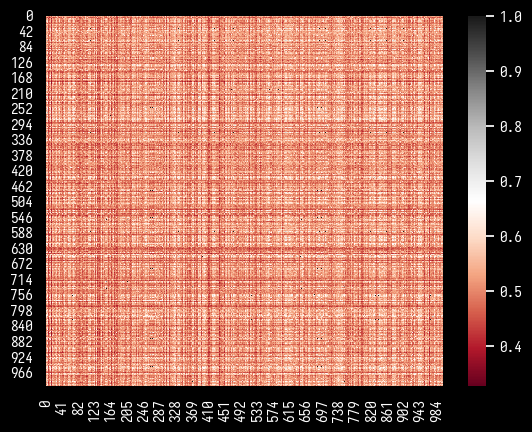

el promedio de la cosine sim es 0.523442435357774


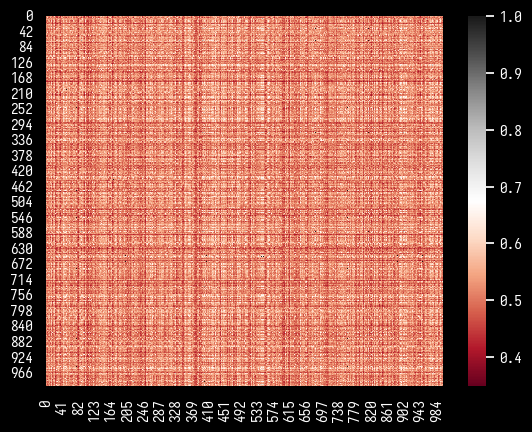

el promedio de la cosine sim es 0.5268558325272649


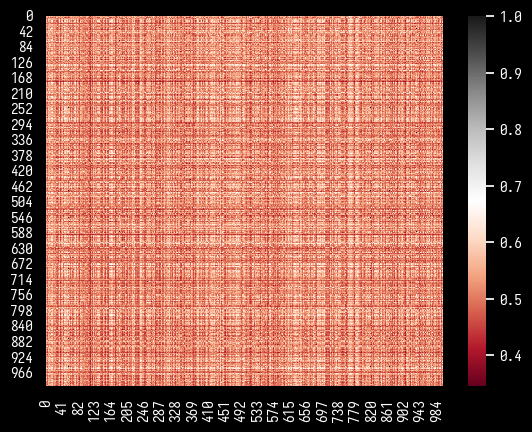

el promedio de la cosine sim es 0.5343792131945448


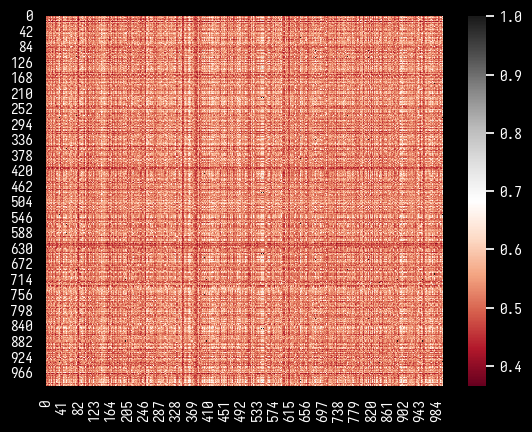

el promedio de la cosine sim es 0.5394772120488351


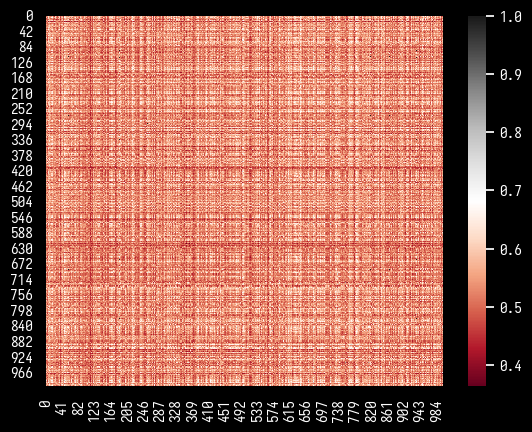

el promedio de la cosine sim es 0.5437888009474555


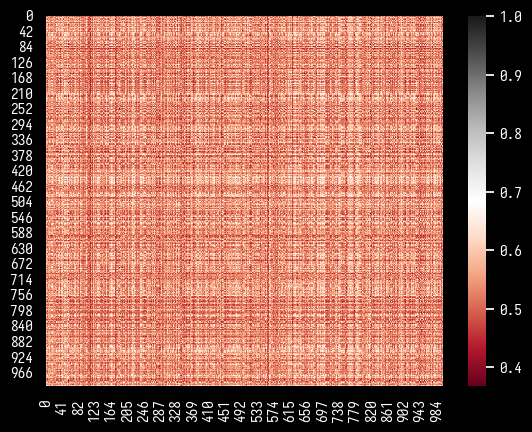

In [29]:
# 4C2 = 6 graficos que podriamos analizar
from itertools import combinations
samples = [sample_y1,sample_y2,sample_y3,sample_y4]

for pair in combinations(samples,2):
    sim = cosine_similarity(pair[0],pair[1])
    print(f'el promedio de la cosine sim es {sim.mean()}')
    sns.heatmap(sim,cmap='RdGy')
    plt.show()


Vale esto es sumamente desilucionante JAJAJAJA, la verdad es que esperaba ver una difrencia mas grande entre las cosine similarities, y los heatmaps no son muy reveladores. vamos a probar algo mas.



Mi idea es la siguiente, tomar el centroide de cada grupo, es decir el vector cuyo $i\text{-esimo}$ componente es el promedio del $i\text{-esimo}$ componente de los vectores del grupo y tomar digamos los primeros 100 vectores  mas cercanos bajo la  distancia euclidiana a ese centroide o algo similar, la hipotesis es que va a ver mas vectores cerca que pertenecen a la misma clase de la que se saco dicho centroide, igual esto lo haremos solo con la muestra


de ser cierto esto nos podria hablar de que hay diferentes regiones con diferentes densidades de cada uno de los grupos


In [30]:
dfs = []


for i,s in enumerate(samples):
    temp_df  = pd.DataFrame(s)
    temp_df['y'] = f'y{i + 1}'
    dfs.append(temp_df)

df_samples = pd.concat(dfs)


centroids = dict()


# sacar centroides
for grp in df_samples.groupby('y'):
    centroid = grp[1].iloc[:,:-1].mean().values
    centroids[grp[0]] = centroid



# sacar columna de distancia
for k,v in centroids.items():

    
    df_samples[f'distance_{k}_centroid'] = df_samples[vec_cols].apply(lambda x: np.linalg.norm(v - x),axis=1)

In [31]:
df_samples

,w1,w2,w3,w4,w5,w6,w7,w8,w9,w10,...,w764,w765,w766,w767,w768,y,distance_y1_centroid,distance_y2_centroid,distance_y3_centroid,distance_y4_centroid
98009,-0.014133,-0.023995,0.015224,-0.110804,-0.016538,-0.012022,0.031615,0.017624,0.000238,-0.043515,...,-0.008745,0.005466,0.012386,0.026588,-0.035259,y1,0.634352,0.720505,0.733358,0.700440
7834,0.006486,-0.061826,0.003474,-0.072386,0.035909,-0.028351,-0.005178,-0.004360,0.000360,-0.006800,...,0.015935,0.043836,-0.017214,0.035735,0.020954,y1,0.668524,0.756880,0.731829,0.689371
18498,-0.032552,0.002941,0.018178,-0.094309,0.011643,-0.007556,-0.032401,0.029303,0.000941,-0.030233,...,-0.048860,0.003745,0.012120,-0.006435,0.020374,y1,0.657893,0.623918,0.664156,0.687783
124268,0.008477,-0.060109,0.048389,-0.117961,0.033283,-0.009596,-0.012794,-0.006811,0.008509,-0.047948,...,-0.034926,0.039210,-0.010807,0.012581,0.000636,y1,0.695326,0.789952,0.765311,0.736155
93197,-0.004703,-0.016774,0.024487,-0.098404,0.004803,-0.011075,0.008995,-0.001537,0.013074,0.005973,...,0.011883,-0.005330,0.006071,0.054242,0.039616,y1,0.677643,0.743404,0.732821,0.721462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
366044,-0.006394,0.026668,0.008431,-0.089868,0.006995,0.010102,0.027073,0.035957,0.024247,-0.001385,...,0.008672,-0.005138,0.019008,-0.040703,-0.012244,y4,0.708598,0.667125,0.678738,0.684405
356927,-0.047689,0.008924,-0.013469,-0.132148,-0.045649,0.017522,-0.016267,0.035491,-0.063084,-0.036630,...,-0.000161,0.033815,0.015767,0.016569,0.012698,y4,0.760558,0.762356,0.745271,0.726900
364055,-0.044499,-0.038921,0.054354,-0.121754,0.006503,0.010491,0.014394,0.004826,-0.014776,-0.029593,...,-0.030209,-0.011182,0.014051,0.022731,0.023548,y4,0.693220,0.686102,0.702548,0.633250
360337,0.002804,-0.049164,-0.006255,-0.065385,0.009272,0.005734,-0.010274,0.003086,-0.011943,0.015507,...,0.003831,0.019805,-0.016373,0.019924,-0.010082,y4,0.750674,0.736714,0.726489,0.623261


/tmp/ipykernel_19886/3157689296.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_19886/3157689296.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_19886/3157689296.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
/tmp/ipykernel_19886/3157689296.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


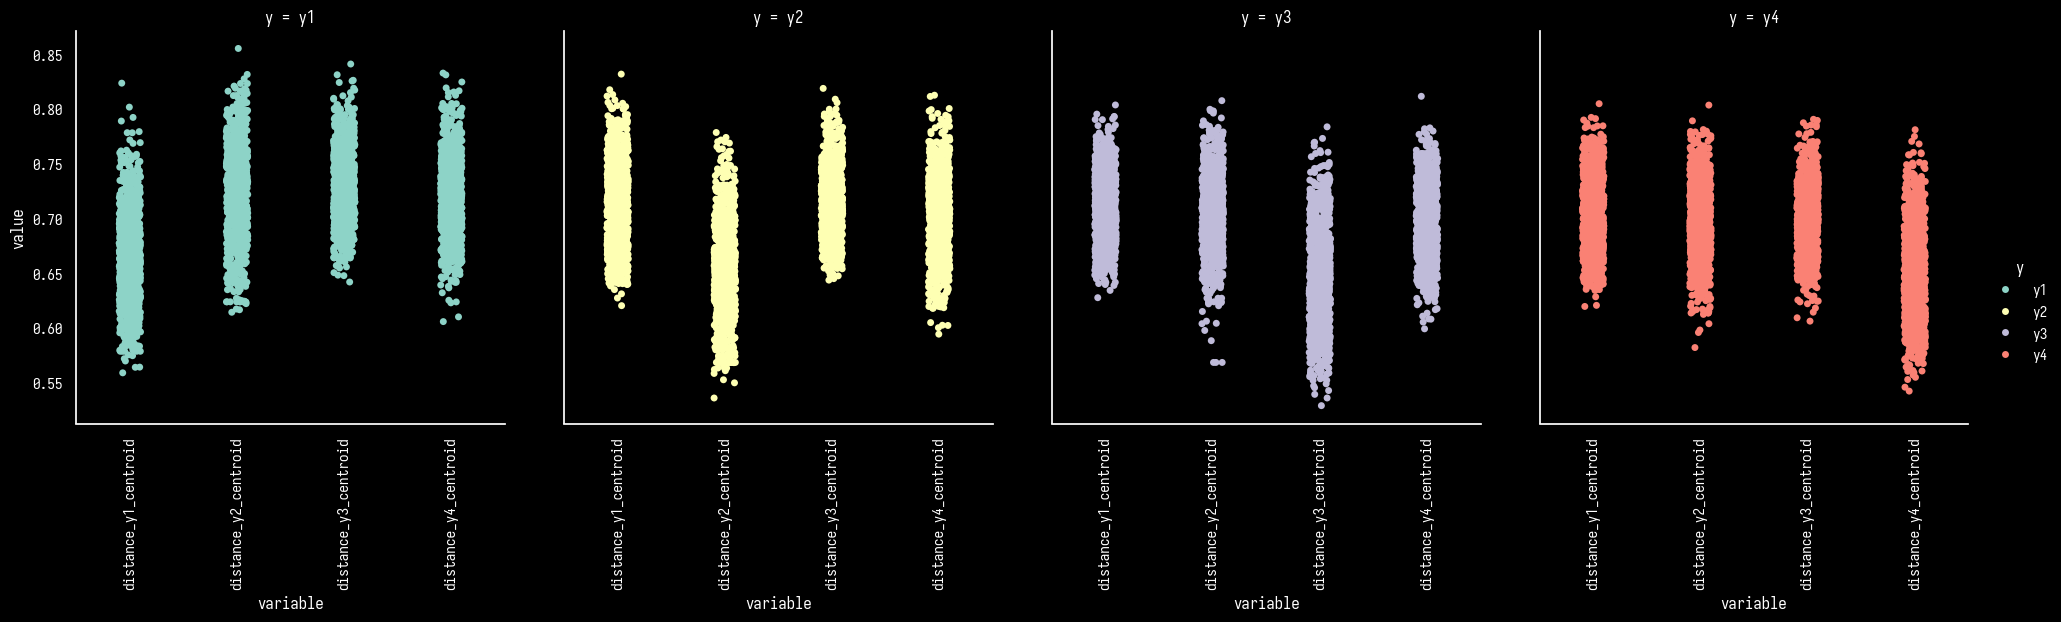

In [32]:
melted_df = pd.melt(df_samples.iloc[:,-5:],id_vars='y')

f = sns.catplot(melted_df,x='variable',y='value',hue='y',col='y')

for ax in f.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


Se confirma la hipotesis que planteamos, los vectores de una clase estan mas cerca o compactos en unas regiones que en otras, no obstante pareciera que gran parte de ese rango es compartido, vamos usar otro plot para saber la concentracion de datos

<Axes: xlabel='variable', ylabel='value'>

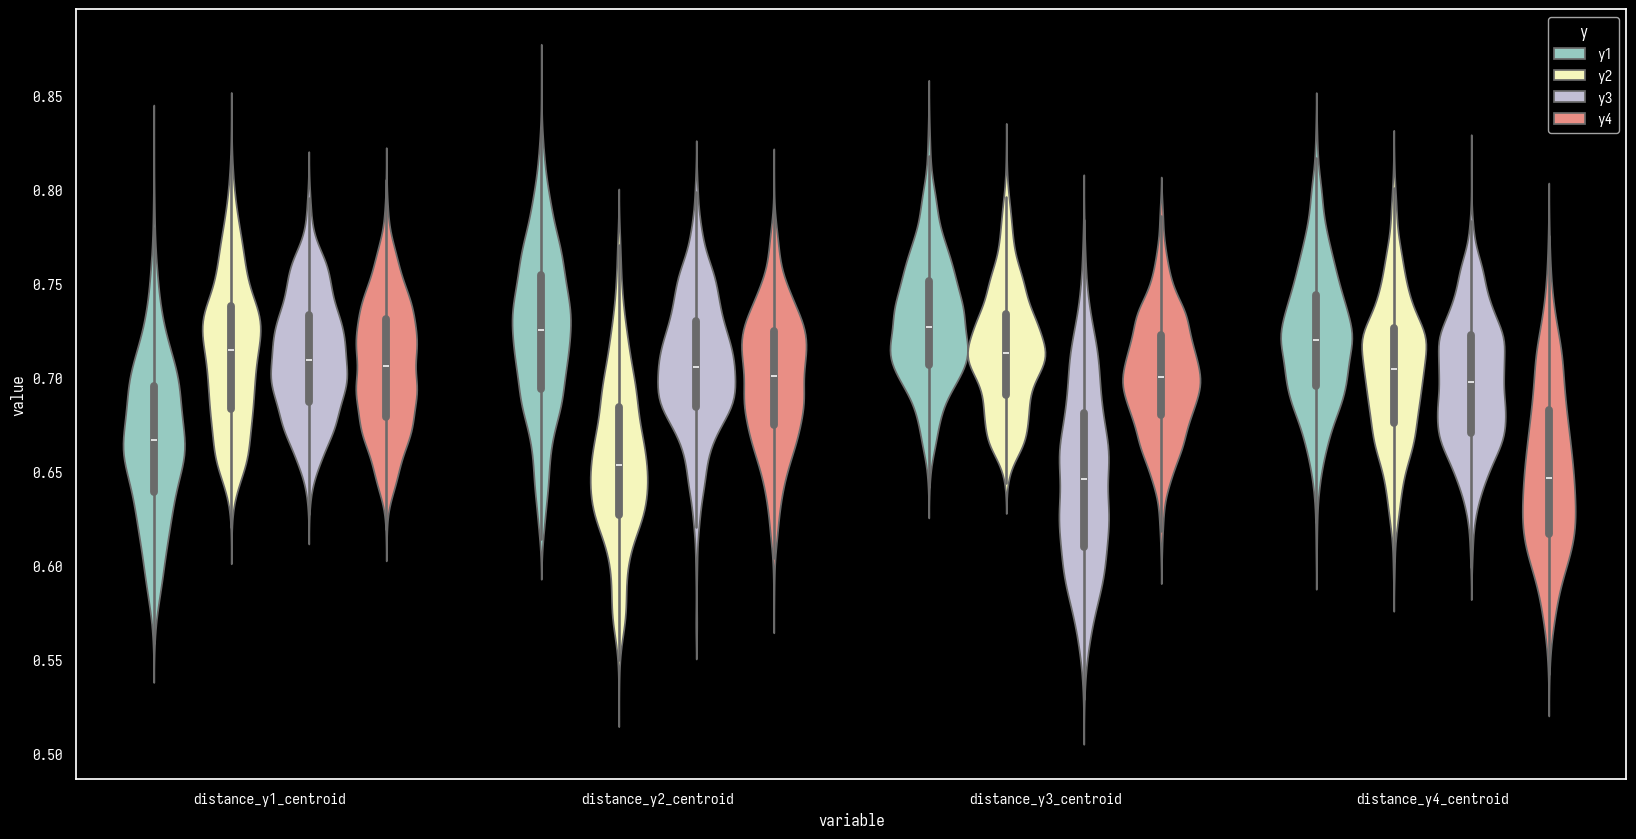

In [33]:


fig,ax = plt.subplots(figsize=(20,10))
sns.violinplot(melted_df,x='variable',y='value',hue='y',ax=ax)



No esta tan mal, usualmente la mediana de la clase que pertenece esta mas cerca que la mayoria de los datos de las clases que no pertenecen. es una buena señal e incluso nos dice que  KN-neighborts 


Por ultimo vamos a analizar el silhuette coeficient que de forma vaga se puede decir que mide que tan nitidos o claros son los clusteres. se suele utilizar  para evaluar rendimiento de algoritmos de clustering pero creo que aqui no esta mal usarlos para ver que tan distinguible son los grupos en nuestro espacio de altas dimensiones. es una metrica que esta acotada en $[-1,1]$ siendo 1 que los clusteres estan bien definidos, cero y cerca a 0 que se overlappean y negativo de que en general los puntos estan mas cerca de los puntos de otras clases que los de si mismos

In [34]:
from sklearn.metrics import silhouette_score

silhouette_score(df_samples[vec_cols],df_samples['y'])

np.float64(0.02888438408696064)

![me quero morir](https://www.fanaticosdelasmascotas.cl/wp-content/uploads/2020/10/crying-cat.jpg)

un silhuette tan bajo solo indica que probablemente  se necesiten redes para poder aproximar las fronteras reales, y eso a mi computadorcita no le gusta

### Referencias


- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html
- https://saturncloud.io/blog/how-to-clear-jupyter-memory-without-restarting-notebook/
- https://qdrant.tech/
- https://www.geeksforgeeks.org/machine-learning/what-is-silhouette-score/
- https://ai.google.dev/gemini-api/docs/embeddings#model-versions
- https://www.analyticsvidhya.com/blog/2022/06/stemming-vs-lemmatization-in-nlp-must-know-differences/
- https://www.geeksforgeeks.org/nlp/nlp-how-tokenizing-text-sentence-words-works/
- https://www.tigerdata.com/blog/a-beginners-guide-to-vector-embeddings
- https://www.youtube.com/watch?v=a2Kg2_l3L8M